In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal, wasserstein_distance
from statsmodels.tsa.arima_process import ArmaProcess
import matplotlib as mpl

mpl.rcParams['font.size'] = 14


def build_arma53_process():
    """Construct the ARMA(5,3) model using statsmodels' lag-polynomial sign convention."""
    ar = np.array([1.0, -0.7, 0.25, 0.18, -0.12, 0.08], dtype=float)
    ma = np.array([1.0, 0.5, -0.4, 0.25], dtype=float)
    process = ArmaProcess(ar, ma)
    if not process.isstationary:
        raise ValueError('The specified AR polynomial is not stationary.')
    return process


def simulate_arma53_path(n, burnin=1000, rng=None, process=None):
    """Simulate one length-n realization with standard normal innovations and burn-in removal."""
    rng = np.random.default_rng() if rng is None else rng
    process = build_arma53_process() if process is None else process
    simulated = process.generate_sample(
        nsample=n,
        burnin=burnin,
        distrvs=lambda size: rng.standard_normal(size=size),
    )
    return np.asarray(simulated, dtype=float)


def generate_arma53_realizations(m, n, burnin=1000, rng=None, process=None):
    """Generate m independent ARMA(5,3) realizations and return an array of shape (m, n)."""
    rng = np.random.default_rng() if rng is None else rng
    process = build_arma53_process() if process is None else process
    return np.vstack([
        simulate_arma53_path(n=n, burnin=burnin, rng=rng, process=process)
        for _ in range(m)
    ])


def theoretical_autocovariances(max_lag, process=None):
    """Return the exact model-implied autocovariances gamma(0), ..., gamma(max_lag)."""
    process = build_arma53_process() if process is None else process
    return np.asarray(process.acovf(nobs=max_lag + 1), dtype=float)


def theoretical_autocorrelations(max_lag, process=None):
    """Return r_k = gamma(k) / gamma(0) for k = 0, ..., max_lag."""
    gamma_values = theoretical_autocovariances(max_lag=max_lag, process=process)
    return gamma_values / gamma_values[0]


def theoretical_variance(process=None):
    """Return the exact marginal variance tau^2 = gamma(0)."""
    return float(theoretical_autocovariances(max_lag=0, process=process)[0])


def bivariate_standard_normal_cdf(u, v, rho):
    """Evaluate Phi_2(u, v; rho), including the singular rho = +/- 1 edge cases."""
    u_array, v_array = np.broadcast_arrays(np.asarray(u, dtype=float), np.asarray(v, dtype=float))

    if np.isclose(rho, 1.0):
        values = norm.cdf(np.minimum(u_array, v_array))
    elif np.isclose(rho, -1.0):
        values = np.maximum(norm.cdf(u_array) + norm.cdf(v_array) - 1.0, 0.0)
    else:
        points = np.column_stack([u_array.ravel(), v_array.ravel()])
        covariance = np.array([[1.0, rho], [rho, 1.0]], dtype=float)
        values = multivariate_normal(
            mean=np.zeros(2),
            cov=covariance,
            allow_singular=True,
        ).cdf(points).reshape(u_array.shape)

    if values.ndim == 0:
        return float(values)
    return values


def theoretical_covariance_kernel(x, y, autocovariances, truncation_lag=None):
    """
    Compute the truncated Gaussian covariance kernel
        Gamma_K(x, y) = Cov_0(x, y) + 2 * sum_{k=1}^K Cov_k(x, y),
    where the infinite ARMA lag sum is approximated by truncation at lag K.
    """
    gamma_values = np.asarray(autocovariances, dtype=float)
    if truncation_lag is None:
        truncation_lag = len(gamma_values) - 1
    gamma_values = gamma_values[:truncation_lag + 1]

    tau2 = gamma_values[0]
    tau = np.sqrt(tau2)
    u = x / tau
    v = y / tau
    marginal_product = norm.cdf(u) * norm.cdf(v)

    kernel_value = bivariate_standard_normal_cdf(u, v, 1.0) - marginal_product
    for lag in range(1, len(gamma_values)):
        rho = gamma_values[lag] / tau2
        kernel_value += 2.0 * (bivariate_standard_normal_cdf(u, v, rho) - marginal_product)
    return float(kernel_value)


def build_covariance_matrix(grid, autocovariances, truncation_lag=None):
    """Build Sigma_{ij} = Gamma_K(x_i, x_j) on a finite grid, using symmetry for efficiency."""
    grid = np.asarray(grid, dtype=float)
    gamma_values = np.asarray(autocovariances, dtype=float)
    if truncation_lag is None:
        truncation_lag = len(gamma_values) - 1
    gamma_values = gamma_values[:truncation_lag + 1]

    tau2 = gamma_values[0]
    tau = np.sqrt(tau2)
    standardized_grid = grid / tau
    marginal_cdf = norm.cdf(standardized_grid)

    upper_i, upper_j = np.triu_indices(grid.size)
    u_points = standardized_grid[upper_i]
    v_points = standardized_grid[upper_j]
    marginal_product_upper = marginal_cdf[upper_i] * marginal_cdf[upper_j]

    upper_values = bivariate_standard_normal_cdf(u_points, v_points, 1.0) - marginal_product_upper
    for lag in range(1, len(gamma_values)):
        rho = gamma_values[lag] / tau2
        upper_values += 2.0 * (bivariate_standard_normal_cdf(u_points, v_points, rho) - marginal_product_upper)

    sigma = np.empty((grid.size, grid.size), dtype=float)
    sigma[upper_i, upper_j] = upper_values
    sigma[upper_j, upper_i] = upper_values
    return sigma


def stabilize_covariance_matrix(covariance_matrix, tolerance=1e-10, jitter=1e-10):
    """Symmetrize Sigma and add a tiny diagonal jitter only if the smallest eigenvalue is too small."""
    stabilized = 0.5 * (np.asarray(covariance_matrix, dtype=float) + np.asarray(covariance_matrix, dtype=float).T)
    min_eigenvalue = float(np.linalg.eigvalsh(stabilized).min())
    added_jitter = 0.0
    if min_eigenvalue < tolerance:
        added_jitter = tolerance - min_eigenvalue + jitter
        stabilized = stabilized + added_jitter * np.eye(stabilized.shape[0])
    return stabilized, min_eigenvalue, added_jitter


def simulate_gaussian_process_draw(covariance_matrix, rng=None):
    """Simulate one Gaussian process draw on the grid from N(0, Sigma)."""
    rng = np.random.default_rng() if rng is None else rng
    stabilized_covariance, _, _ = stabilize_covariance_matrix(covariance_matrix)
    cholesky_factor = np.linalg.cholesky(stabilized_covariance)
    return cholesky_factor @ rng.standard_normal(stabilized_covariance.shape[0])


def gaussian_functional_integral(z_values, grid):
    """Approximate integral |Z(x)| dx by the trapezoidal rule over the chosen grid."""
    return float(np.trapz(np.abs(np.asarray(z_values, dtype=float)), x=np.asarray(grid, dtype=float)))


def pairwise_wasserstein_distances(realizations):
    """Compute all pairwise 1D Wasserstein-1 distances W(F_n^(i), F_n^(j)) for i < j."""
    realizations = np.asarray(realizations, dtype=float)
    num_realizations = realizations.shape[0]
    distances = np.empty(num_realizations * (num_realizations - 1) // 2, dtype=float)

    index = 0
    for i in range(num_realizations - 1):
        for j in range(i + 1, num_realizations):
            distances[index] = wasserstein_distance(realizations[i], realizations[j])
            index += 1
    return distances


def simulate_gaussian_functional_samples(covariance_matrix, grid, num_draws, rng=None):
    """Simulate many Gaussian draws on the grid and return the sampled L1 functionals."""
    rng = np.random.default_rng() if rng is None else rng
    stabilized_covariance, min_eigenvalue, added_jitter = stabilize_covariance_matrix(covariance_matrix)
    cholesky_factor = np.linalg.cholesky(stabilized_covariance)
    gaussian_draws = rng.standard_normal(size=(num_draws, stabilized_covariance.shape[0])) @ cholesky_factor.T
    functional_values = np.trapz(np.abs(gaussian_draws), x=np.asarray(grid, dtype=float), axis=1)
    return np.asarray(functional_values, dtype=float), stabilized_covariance, min_eigenvalue, added_jitter


In [2]:
# Reproducible simulation of 100 dependent Gaussian ARMA(5,3) sample paths of length n = 1000.
seed = 20260325
rng = np.random.default_rng(seed)
arma_process = build_arma53_process()

num_realizations = 100
sample_size = 1000
burnin = 1000

paths = generate_arma53_realizations(
    m=num_realizations,
    n=sample_size,
    burnin=burnin,
    rng=rng,
    process=arma_process,
)
tau2 = theoretical_variance(process=arma_process)

print(f'paths.shape = {paths.shape}')
print(f'Empirical mean over all simulated entries: {paths.mean():.6f}')
print(f'Empirical variance over all simulated entries: {paths.var(ddof=0):.6f}')
print(f'Theoretical marginal variance tau^2: {tau2:.6f}')
print('First 10 observations of the first realization:')
print(np.round(paths[0, :10], 6))


paths.shape = (100, 1000)
Empirical mean over all simulated entries: 0.003001
Empirical variance over all simulated entries: 2.539814
Theoretical marginal variance tau^2: 2.545104
First 10 observations of the first realization:
[-2.708553 -0.734327  3.155608  2.80541   2.113456  2.123361  0.52992
 -1.581095 -0.232031  2.17215 ]


In [3]:
# Part A: empirical pairwise Wasserstein distances across the 100 simulated realizations.
pairwise_W = pairwise_wasserstein_distances(paths)
scaled_pairwise_W = np.sqrt(sample_size) * pairwise_W

print(f'Number of pairwise distances: {pairwise_W.size}')
print(f'Unscaled W mean/std: {pairwise_W.mean():.6f} / {pairwise_W.std(ddof=1):.6f}')
print(f'Scaled sqrt(n) * W mean/std: {scaled_pairwise_W.mean():.6f} / {scaled_pairwise_W.std(ddof=1):.6f}')
print(
    'Scaled sqrt(n) * W min/median/max: '
    f'{scaled_pairwise_W.min():.6f} / {np.median(scaled_pairwise_W):.6f} / {scaled_pairwise_W.max():.6f}'
)

# Part B: Gaussian limiting approximation based on the theoretical ARMA covariance kernel.
tau = np.sqrt(tau2)
grid_size = 301
grid = np.linspace(-6.0 * tau, 6.0 * tau, grid_size)
truncation_lag = 200

# The infinite lag sum in Gamma(x, y) is approximated by truncating at lag K = truncation_lag.
theoretical_gamma = theoretical_autocovariances(max_lag=truncation_lag, process=arma_process)
theoretical_rho = theoretical_gamma / theoretical_gamma[0]

print(f'First 10 theoretical autocorrelations r_k for k = 1, ..., 10: {np.round(theoretical_rho[1:11], 6)}')
print(f'Truncation lag K used in the covariance kernel approximation: {truncation_lag}')

Sigma = build_covariance_matrix(grid=grid, autocovariances=theoretical_gamma, truncation_lag=truncation_lag)
symmetry_error = np.max(np.abs(Sigma - Sigma.T))
print(f'Maximum absolute symmetry error in Sigma: {symmetry_error:.3e}')

Sigma_for_simulation, sigma_min_eig, sigma_jitter = stabilize_covariance_matrix(Sigma)
if sigma_jitter > 0.0:
    print(
        'Sigma was stabilized with diagonal jitter '
        f'{sigma_jitter:.3e}; minimum eigenvalue before jitter was {sigma_min_eig:.3e}'
    )
else:
    print(f'Sigma is numerically stable without extra jitter; minimum eigenvalue = {sigma_min_eig:.3e}')

# For G_i - G_j with independent copies, the covariance doubles, so we simulate from N(0, 2 * Sigma).
num_gaussian_draws = 5000
gaussian_rng = np.random.default_rng(seed + 1)
gaussian_limit_samples, covariance_used, limit_min_eig, limit_jitter = simulate_gaussian_functional_samples(
    covariance_matrix=2.0 * Sigma_for_simulation,
    grid=grid,
    num_draws=num_gaussian_draws,
    rng=gaussian_rng,
)

print(f'Number of Gaussian limit draws: {gaussian_limit_samples.size}')
print(f'Gaussian approximation mean/std: {gaussian_limit_samples.mean():.6f} / {gaussian_limit_samples.std(ddof=1):.6f}')
print(
    'Gaussian approximation min/median/max: '
    f'{gaussian_limit_samples.min():.6f} / {np.median(gaussian_limit_samples):.6f} / {gaussian_limit_samples.max():.6f}'
)
if limit_jitter > 0.0:
    print(
        'The doubled covariance 2 * Sigma required additional jitter '
        f'{limit_jitter:.3e}; minimum eigenvalue before jitter was {limit_min_eig:.3e}'
    )

print('\nConcise mean/std comparison:')
print(f'Empirical scaled pairwise mean/std: {scaled_pairwise_W.mean():.6f} / {scaled_pairwise_W.std(ddof=1):.6f}')
print(f'Gaussian approximation mean/std: {gaussian_limit_samples.mean():.6f} / {gaussian_limit_samples.std(ddof=1):.6f}')


Number of pairwise distances: 4950
Unscaled W mean/std: 0.099843 / 0.034458
Scaled sqrt(n) * W mean/std: 3.157319 / 1.089656
Scaled sqrt(n) * W min/median/max: 1.079931 / 2.970267 / 8.293822
First 10 theoretical autocorrelations r_k for k = 1, ..., 10: [ 0.572884  0.022707 -0.142169 -0.134145 -0.0737   -0.03557  -0.001204
  0.016592  0.020205  0.01184 ]
Truncation lag K used in the covariance kernel approximation: 200
Maximum absolute symmetry error in Sigma: 0.000e+00
Sigma was stabilized with diagonal jitter 1.053e-10; minimum eigenvalue before jitter was 9.472e-11
Number of Gaussian limit draws: 5000
Gaussian approximation mean/std: 3.367685 / 1.293306
Gaussian approximation min/median/max: 1.118522 / 3.098130 / 10.350690

Concise mean/std comparison:
Empirical scaled pairwise mean/std: 3.157319 / 1.089656
Gaussian approximation mean/std: 3.367685 / 1.293306


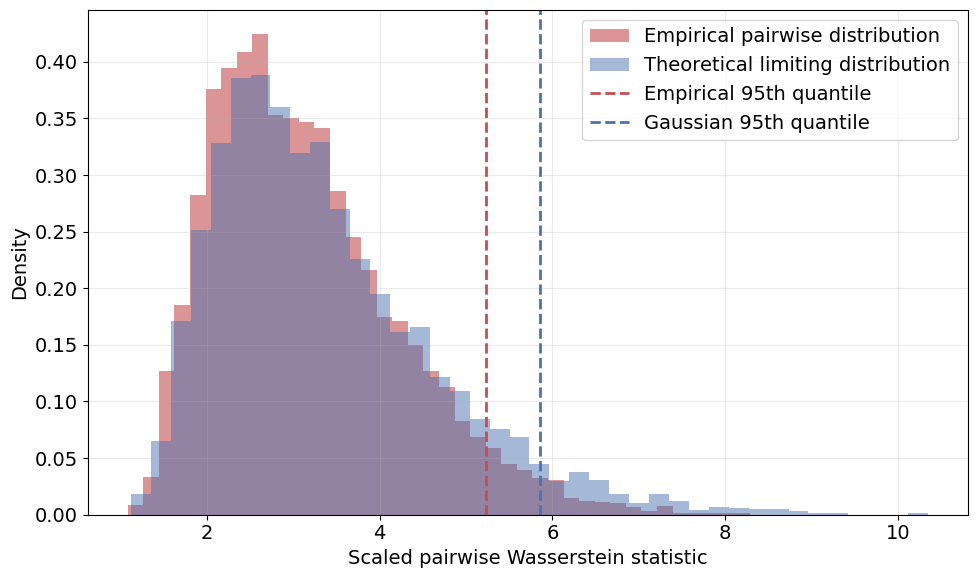

Final mean/std comparison:
Empirical scaled pairwise mean/std: 3.157319 / 1.089656
Gaussian approximation mean/std: 3.367685 / 1.293306


In [10]:
# Overlay the empirical scaled pairwise Wasserstein distribution and the Gaussian limit approximation.
plt.figure(figsize=(10, 6))
num_bins = 40

plt.hist(
    scaled_pairwise_W,
    bins=num_bins,
    density=True,
    alpha=0.6,
    color='#c44e52',
    label=r'Empirical pairwise distribution',
)
plt.hist(
    gaussian_limit_samples,
    bins=num_bins,
    density=True,
    alpha=0.5,
    color='#4c72b0',
    label='Theoretical limiting distribution',
)

empirical_q95 = np.quantile(scaled_pairwise_W, 0.95)
gaussian_q95 = np.quantile(gaussian_limit_samples, 0.95)

plt.axvline(empirical_q95, color='#c44e52', linestyle='--', linewidth=2, label=f'Empirical 95th quantile')
plt.axvline(gaussian_q95, color='#4c72b0', linestyle='--', linewidth=2, label=f'Gaussian 95th quantile')

# plt.title('ARMA(5,3): Empirical Pairwise Wasserstein Distances vs Gaussian Approximation')
plt.xlabel(r'Scaled pairwise Wasserstein statistic')
plt.ylabel('Density')
plt.legend(frameon=True)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('Final mean/std comparison:')
print(f'Empirical scaled pairwise mean/std: {scaled_pairwise_W.mean():.6f} / {scaled_pairwise_W.std(ddof=1):.6f}')
print(f'Gaussian approximation mean/std: {gaussian_limit_samples.mean():.6f} / {gaussian_limit_samples.std(ddof=1):.6f}')
